# Log representation leaning with parsed data

## Load Parquet data

In [5]:
!pip3 install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--  Downloading nltk-3.9.2-py3-none-any.whl (1.5 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.6 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.6 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/108.3 kB ? eta -:--:--Collecting click (from nltk)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 4.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd

dataset_name = "BGL"

df = pd.read_parquet(f'Output/{dataset_name}_parsed.parquet', engine='fastparquet')

df.head()

,LineId,Label,EventId,EventTemplate,RawLog
0,1,False,1,<*> <*> <*> <*> <*> RAS KERNEL INFO instructio...,1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005...
1,2,False,1,<*> <*> <*> <*> <*> RAS KERNEL INFO instructio...,1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005...
2,3,False,1,<*> <*> <*> <*> <*> RAS KERNEL INFO instructio...,1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005...
3,4,False,1,<*> <*> <*> <*> <*> RAS KERNEL INFO instructio...,1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005...
4,5,False,1,<*> <*> <*> <*> <*> RAS KERNEL INFO instructio...,1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005...


In [2]:
df.shape

(4747963, 5)

In [3]:
sum(df['Label']) / len(df)

0.07339147335394147

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from nltk.tokenize import RegexpTokenizer
from gensim.models import Word2Vec
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported.")

Libraries imported.


In [5]:
!pip3 install sentence-transformers


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


## 1. Preprocessing: Sliding Window Sequence Generation
### BGL is a stream of logs, so we create sequences using a sliding window.


In [6]:

def create_sequences(df, window_size=10, step_size=1):
    """
    Creates sequences of log templates and corresponding labels.
    """
    X_templates = []
    y_labels = []
    
    # Get data arrays
    templates = df['EventTemplate'].values
    labels = df['Label'].values # Boolean (True=Anomaly)
    
    num_logs = len(df)
    
    print(f"Creating sequences with window_size={window_size}, step_size={step_size}...")
    
    for i in range(0, num_logs - window_size, step_size):
        # Extract window
        window_templates = templates[i : i + window_size]
        window_labels = labels[i : i + window_size]
        
        # Sequence is anomalous if ANY log in the window is anomalous
        is_anomaly = np.any(window_labels)
        anomaly_count = np.sum(window_labels)
        
        X_templates.append(window_templates)
        y_labels.append(anomaly_count/window_size)
        
    return np.array(X_templates), np.array(y_labels)

# Parameters
WINDOW_SIZE = 150
STEP_SIZE = 35

X_seq_text, y_seq = create_sequences(df, WINDOW_SIZE, STEP_SIZE)

print(f"Total sequences: {len(X_seq_text)}")
print(f"Normal sequences: {len(y_seq) - sum(y_seq)}")
print(f"Anomalous sequences: {sum(y_seq)}")

Creating sequences with window_size=150, step_size=35...
Total sequences: 135652
Normal sequences: 125696.64666666658
Anomalous sequences: 9955.353333333416


In [7]:
sum(y_seq)/len(y_seq)

0.07338891673792805

## 2. Subsets splitting Train60%/Test20%/Eval20%

In [8]:

# First split: Train (60%) vs Temp (40%)
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_seq_text, y_seq, test_size=0.4, stratify=y_seq, random_state=42
)

# Second split: Temp (40%) -> Validation (20%) + Test (20%)
# Split Temp in half (0.5 of 0.4 = 0.2)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train set: {X_train_text.shape} - Anomaly Ratio: {sum(y_train)/len(y_train):.2%}")
print(f"Val set:   {X_val_text.shape} - Anomaly Ratio: {sum(y_val)/len(y_val):.2%}")
print(f"Test set:  {X_test_text.shape} - Anomaly Ratio: {sum(y_test)/len(y_test):.2%}")

Train set: (81391, 150) - Anomaly Ratio: 7.34%
Val set:   (27130, 150) - Anomaly Ratio: 7.35%
Test set:  (27131, 150) - Anomaly Ratio: 7.32%


In [9]:
X_train_text[0].shape

(150,)

## 3. Word2Vec

In [10]:
# 3. Feature Learning: Semantic Embeddings (Word2Vec)
# We learn a vector representation for each unique template based on its words.

# Tokenize all unique templates in the training set
unique_templates = np.unique(X_train_text)
tokenizer = RegexpTokenizer(r'\w+')
tokenized_corpus = [tokenizer.tokenize(template.lower()) for template in unique_templates]

# Train Word2Vec
w2v_model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, workers=4, seed=42)

def get_template_vector(template, model):
    """Average word vectors to get template vector"""
    words = tokenizer.tokenize(template.lower())
    word_vectors = [model.wv[w] for w in words if w in model.wv]
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)

# Convert sequences of text templates to sequences of vectors
def vectorize_sequences(sequences, model):
    vectorized = []
    for seq in sequences:
        seq_vec = [get_template_vector(t, model) for t in seq]
        vectorized.append(seq_vec)
    return np.array(vectorized)

print("Vectorizing sequences...")
X_train_vec = vectorize_sequences(X_train_text, w2v_model)
X_val_vec = vectorize_sequences(X_val_text, w2v_model)
X_test_vec = vectorize_sequences(X_test_text, w2v_model)

print(f"Vectorized Train Shape: {X_train_vec.shape}") # (N_samples, Window_Size, Vector_Dim)

Vectorizing sequences...
Vectorized Train Shape: (81391, 150, 100)


In [49]:
import os

os.makedirs('models', exist_ok=True)
w2v_model.save("models/word2vec.model")
print("Word2Vec model saved.")

Word2Vec model saved.


## 4. TF-IDF (Baseline)


In [25]:
# Treats the entire sequence of templates as a single "document".
# Loses temporal order but captures the presence of specific events.

from sklearn.feature_extraction.text import TfidfVectorizer

# Join templates in a sequence to form a "document"
X_train_docs = [" ".join(seq) for seq in X_train_text]
X_test_docs = [" ".join(seq) for seq in X_test_text]

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,3))
X_train_tfidf = tfidf.fit_transform(X_train_docs).toarray()
X_test_tfidf = tfidf.transform(X_test_docs).toarray()

print(f"TF-IDF Train Shape: {X_train_tfidf.shape}")

TF-IDF Train Shape: (81391, 3000)


In [50]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers=2):
        super(LSTMAutoencoder, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        
        # Encoder
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.hidden_to_latent = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.hidden_to_output = nn.Linear(hidden_dim, input_dim)
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        batch_size, seq_len, _ = x.shape
        
        # Encode
        _, (h_n, _) = self.encoder_lstm(x)
        # h_n shape: (num_layers, batch, hidden_dim) -> take last layer
        h_last = h_n[-1] 
        latent = self.hidden_to_latent(h_last) # (batch, latent_dim)
        
        # Decode
        # Repeat latent vector for each time step
        hidden_decoded = self.latent_to_hidden(latent)
        hidden_repeated = hidden_decoded.unsqueeze(1).repeat(1, seq_len, 1)
        
        output_lstm, _ = self.decoder_lstm(hidden_repeated)
        reconstructed = self.hidden_to_output(output_lstm)
        
        return reconstructed, latent

# Hyperparameters
INPUT_DIM = 100 # Word2Vec vector size
HIDDEN_DIM = 32
LATENT_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
LR = 0.001

model = LSTMAutoencoder(INPUT_DIM, HIDDEN_DIM, LATENT_DIM)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Prepare DataLoaders
# For representation learning, we typically train on Normal data to learn "normal" patterns,
# OR train on everything if we just want a general compressor.
# Here, let's train on X_train (which is mixed) to see if the latent space separates them.

# train_dataset = TensorDataset(torch.FloatTensor(X_train_vec))
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# TODO check normal learning vs mixed learning
#filter out anomalous samples for normal training
normal_indices = np.where(y_train == 0)[0]
X_train_normal = X_train_vec[normal_indices]

train_dataset = TensorDataset(torch.FloatTensor(X_train_normal))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(model)

LSTMAutoencoder(
  (encoder_lstm): LSTM(50, 32, batch_first=True)
  (hidden_to_latent): Linear(in_features=32, out_features=16, bias=True)
  (latent_to_hidden): Linear(in_features=16, out_features=32, bias=True)
  (decoder_lstm): LSTM(32, 32, batch_first=True)
  (hidden_to_output): Linear(in_features=32, out_features=50, bias=True)
)


In [50]:
# 5. Training Loop & Visualization

train_losses = []

print("Starting training...")
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for batch in train_loader:
        inputs = batch[0]
        optimizer.zero_grad()
        
        reconstructed, _ = model(inputs)
        loss = criterion(reconstructed, inputs)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.title('LSTM Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

LSTMAutoencoder(
  (encoder_lstm): LSTM(100, 32, num_layers=2, batch_first=True)
  (hidden_to_latent): Linear(in_features=32, out_features=32, bias=True)
  (latent_to_hidden): Linear(in_features=32, out_features=32, bias=True)
  (decoder_lstm): LSTM(32, 32, num_layers=2, batch_first=True)
  (hidden_to_output): Linear(in_features=32, out_features=100, bias=True)
)


Starting training...
Epoch [5/20], Loss: 0.0001
Epoch [5/20], Loss: 0.0001
Epoch [10/20], Loss: 0.0001
Epoch [10/20], Loss: 0.0001
Epoch [15/20], Loss: 0.0001
Epoch [15/20], Loss: 0.0001
Epoch [20/20], Loss: 0.0001
Epoch [20/20], Loss: 0.0001


Starting training...
Epoch [5/20], Loss: 0.0001
Epoch [5/20], Loss: 0.0001
Epoch [10/20], Loss: 0.0001
Epoch [10/20], Loss: 0.0001
Epoch [15/20], Loss: 0.0001
Epoch [15/20], Loss: 0.0001
Epoch [20/20], Loss: 0.0001
Epoch [20/20], Loss: 0.0001


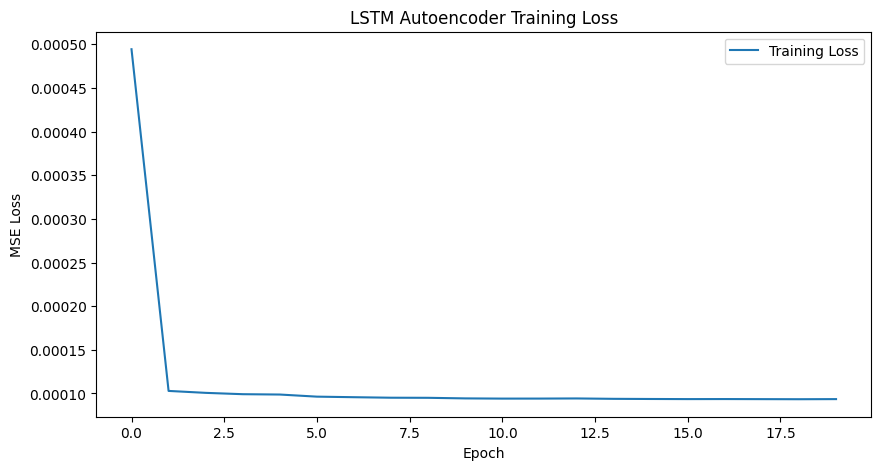

In [51]:
torch.save(model.state_dict(), 'models/lstm_autoencoder.pth')
print("LSTM Autoencoder model saved.")

## 5b. Train Transformer Autoencoder (using BERT embeddings)

## 5. Transformer autoencoder (definition)

In [17]:
# 4b. Model: Transformer Autoencoder
# Uses Self-Attention to capture long-range dependencies in the log sequence.

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerAutoencoder(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, latent_dim=32):
        super(TransformerAutoencoder, self).__init__()
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        
        # Latent projection (Pool the sequence -> Latent)
        self.to_latent = nn.Linear(d_model, latent_dim)
        
        # Decoder projection (Latent -> Sequence)
        self.from_latent = nn.Linear(latent_dim, d_model)
        
        # Decoder (Reconstruct sequence)
        decoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layers, num_layers)
        
        # Output projection
        self.output_proj = nn.Linear(d_model, input_dim)
        
    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        batch_size, seq_len, _ = x.shape
        
        # Embed & Position
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        
        # Encode
        encoded = self.transformer_encoder(x)
        
        # Latent (Mean pooling)
        pooled = encoded.mean(dim=1)
        latent = self.to_latent(pooled)
        
        # Decode
        # Expand latent back to sequence length
        hidden = self.from_latent(latent)
        hidden = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        hidden = self.pos_encoder(hidden)
        
        decoded = self.transformer_decoder(hidden)
        reconstructed = self.output_proj(decoded)
        
        return reconstructed, latent

print("Transformer Autoencoder defined.")

Transformer Autoencoder defined.


## 6. BERT

In [18]:
# 3b. Feature Learning: BERT Embeddings (Contextual Semantics)
# Instead of Word2Vec, we use a pre-trained Transformer (BERT) to embed the templates.
# This captures deeper semantic meaning from the natural language in the logs.

from sentence_transformers import SentenceTransformer

print("Loading BERT model...")
# 'all-MiniLM-L6-v2' is a fast and efficient model for sentence embeddings
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Get all unique templates
all_templates = np.unique(np.concatenate([X_train_text.flatten(), X_val_text.flatten(), X_test_text.flatten()]))
print(f"Unique templates to embed: {len(all_templates)}")

# Generate embeddings for templates (Batch processing is faster)
template_embeddings = bert_model.encode(all_templates)
template_emb_map = {tpl: emb for tpl, emb in zip(all_templates, template_embeddings)}

BERT_DIM = template_embeddings.shape[1]
print(f"BERT Embedding Dimension: {BERT_DIM}")

def vectorize_sequences_bert(sequences, emb_map, dim):
    vectorized = []
    for seq in sequences:
        # Map each template in the sequence to its BERT embedding
        seq_vec = [emb_map.get(t, np.zeros(dim)) for t in seq]
        vectorized.append(seq_vec)
    return np.array(vectorized)

print("Vectorizing sequences with BERT...")
X_train_bert = vectorize_sequences_bert(X_train_text, template_emb_map, BERT_DIM)
X_test_bert = vectorize_sequences_bert(X_test_text, template_emb_map, BERT_DIM)

print(f"BERT Train Shape: {X_train_bert.shape}")

Loading BERT model...
Unique templates to embed: 1347
Unique templates to embed: 1347
BERT Embedding Dimension: 384
Vectorizing sequences with BERT...
BERT Embedding Dimension: 384
Vectorizing sequences with BERT...
BERT Train Shape: (56974, 100, 384)
BERT Train Shape: (56974, 100, 384)


In [ ]:
# Use BERT embeddings as input
train_dataset_bert = TensorDataset(torch.FloatTensor(X_train_bert))
train_loader_bert = DataLoader(train_dataset_bert, batch_size=32, shuffle=True)

transformer_model = TransformerAutoencoder(input_dim=BERT_DIM, d_model=64, latent_dim=32)
optimizer_trans = torch.optim.Adam(transformer_model.parameters(), lr=0.001)

print("Training Transformer Autoencoder with BERT embeddings...")
trans_losses = []

transformer_model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for batch in train_loader_bert:
        inputs = batch[0]
        optimizer_trans.zero_grad()
        
        reconstructed, _ = transformer_model(inputs)
        loss = criterion(reconstructed, inputs)
        
        loss.backward()
        optimizer_trans.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader_bert)
    trans_losses.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(trans_losses, label='Transformer Loss')
plt.title('Transformer Autoencoder Training Loss')
plt.show()

Running t-SNE...


Running t-SNE...


/Users/michalklos/Documents/Studia2025/Magisterka/Notebooks/.venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Running t-SNE...


/Users/michalklos/Documents/Studia2025/Magisterka/Notebooks/.venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


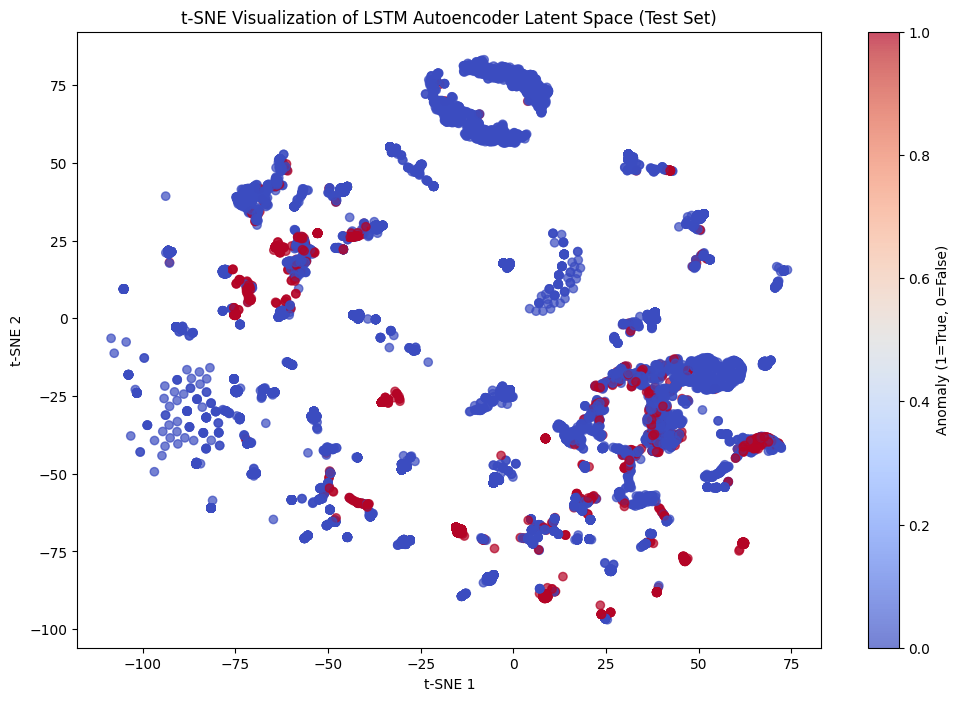

Visualization complete. If clusters are separated, the representation is effective.


Training Transformer Autoencoder with BERT embeddings...


Training Transformer Autoencoder with BERT embeddings...


KeyboardInterrupt: 

In [19]:
# 6. Latent Space Visualization (t-SNE)
# Extract latent vectors for the Test set and visualize

model.eval()
with torch.no_grad():
    # Get latent vectors for test set
    _, latent_test = model(torch.FloatTensor(X_test_vec))
    latent_test_np = latent_test.numpy()

# t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(latent_test_np)

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_test, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='Anomaly (1=True, 0=False)')
plt.title('t-SNE Visualization of LSTM Autoencoder Latent Space (Test Set)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

print("Visualization complete. If clusters are separated, the representation is effective.")

## Eval

Running t-SNE...


Running t-SNE...


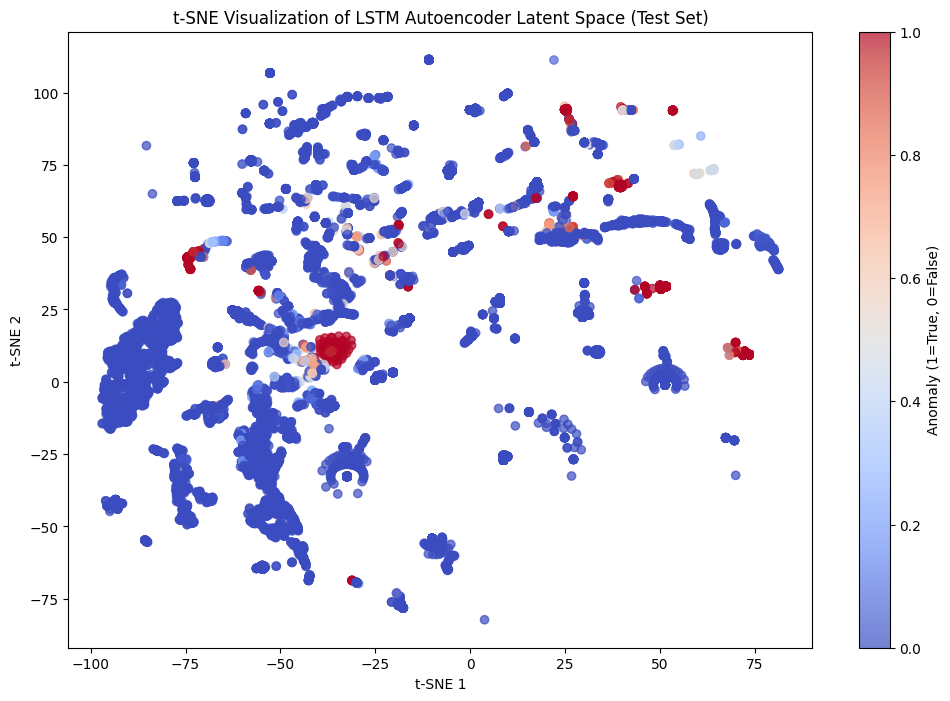

Visualization complete. If clusters are separated, the representation is effective.


In [52]:
# 6b. Compare Latent Spaces (LSTM vs Transformer vs TF-IDF)

# Get Transformer Latent
transformer_model.eval()
with torch.no_grad():
    _, latent_trans = transformer_model(torch.FloatTensor(X_test_bert))
    latent_trans_np = latent_trans.numpy()

# Run t-SNE for all
print("Running t-SNE for comparison...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# 1. LSTM (Word2Vec)
emb_lstm = tsne.fit_transform(latent_test_np)

# 2. Transformer (BERT)
emb_trans = tsne.fit_transform(latent_trans_np)

# 3. TF-IDF (PCA first to reduce dim for t-SNE speed)
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
tfidf_reduced = pca.fit_transform(X_test_tfidf)
emb_tfidf = tsne.fit_transform(tfidf_reduced)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LSTM
scatter1 = axes[0].scatter(emb_lstm[:, 0], emb_lstm[:, 1], c=y_test, cmap='coolwarm', alpha=0.6)
axes[0].set_title('LSTM Autoencoder (Word2Vec)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# Transformer
scatter2 = axes[1].scatter(emb_trans[:, 0], emb_trans[:, 1], c=y_test, cmap='coolwarm', alpha=0.6)
axes[1].set_title('Transformer Autoencoder (BERT)')
axes[1].set_xlabel('t-SNE 1')

# TF-IDF
scatter3 = axes[2].scatter(emb_tfidf[:, 0], emb_tfidf[:, 1], c=y_test, cmap='coolwarm', alpha=0.6)
axes[2].set_title('TF-IDF (Baseline)')
axes[2].set_xlabel('t-SNE 1')

plt.colorbar(scatter3, ax=axes.ravel().tolist(), label='Anomaly')
plt.show()

In [56]:

from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, confusion_matrix

def evaluate_autoencoder(model, X_vec, y_true, threshold_percentile=95):
    """
    Evaluates the Autoencoder by calculating reconstruction error and 
    using it as an anomaly score.
    """
    model.eval()
    criterion = nn.MSELoss(reduction='none') # Calculate loss per sample
    
    # 1. Calculate Reconstruction Error for all samples
    with torch.no_grad():
        inputs = torch.FloatTensor(X_vec)
        reconstructed, _ = model(inputs)
        
        # MSE per sequence: mean over sequence length and feature dim
        # shape: (batch, seq_len, feature_dim)
        loss = criterion(reconstructed, inputs) 
        # Mean over seq_len (dim 1) and feature_dim (dim 2) -> (batch,)
        reconstruction_errors = torch.mean(loss, dim=[1, 2]).numpy()
        
    # 2. Determine Threshold (using only Normal data in the set if possible, or percentile of all)
    # Ideally, threshold is set on a Validation set. Here we use a percentile of the current set for demo.
    threshold = np.percentile(reconstruction_errors, threshold_percentile)
    
    # 3. Predict: Error > Threshold = Anomaly (1)
    y_pred = reconstruction_errors
    
    # 4. Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, reconstruction_errors)
    
    print(f"--- Evaluation Metrics (Threshold = {threshold:.4f}) ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    
    # 5. Plot Error Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(reconstruction_errors[y_true==0], color='blue', label='Normal', kde=True, stat="density", alpha=0.4)
    sns.histplot(reconstruction_errors[y_true==1], color='red', label='Anomaly', kde=True, stat="density", alpha=0.4)
    plt.axvline(threshold, color='k', linestyle='--', label='Threshold')
    plt.title('Reconstruction Error Distribution')
    plt.xlabel('Mean Squared Error')

    # --- Scaling Options ---

    plt.yscale('log')

    plt.legend()
    plt.show()
    
    return reconstruction_errors, y_pred

print("Evaluating LSTM Autoencoder on Test Set...")
# Note: We use the Test set here. In a real pipeline, tune threshold on Val, test on Test.
errors, predictions = evaluate_autoencoder(model, X_test_vec, y_test, threshold_percentile=91)

Evaluating LSTM Autoencoder on Test Set...


Evaluating LSTM Autoencoder on Test Set...


ValueError: continuous is not supported

In [ ]:
def evaluate_autoencoder(model, X_vec, y_true, threshold_percentile=95, y_max=None, log_scale=False):
    """
    Evaluates the Autoencoder by calculating reconstruction error and 
    using it as an anomaly score.
    """
    model.eval()
    criterion = nn.MSELoss(reduction='none') # Calculate loss per sample
    
    # 1. Calculate Reconstruction Error for all samples
    with torch.no_grad():
        inputs = torch.FloatTensor(X_vec)
        reconstructed, _ = model(inputs)
        
        # MSE per sequence: mean over sequence length and feature dim
        loss = criterion(reconstructed, inputs) 
        reconstruction_errors = torch.mean(loss, dim=[1, 2]).numpy()
        
    # 2. Determine Threshold
    threshold = np.percentile(reconstruction_errors, threshold_percentile)
    
    # 3. Predict: Error > Threshold = Anomaly (1)
    y_pred = (reconstruction_errors > threshold).astype(int)  # FIX: Convert to binary
    
    # 4. Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, reconstruction_errors)  # Use continuous errors for AUC
    
    print(f"--- Evaluation Metrics (Threshold = {threshold:.4f}) ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    
    # 5. Plot Error Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(reconstruction_errors[y_true==0], color='blue', label='Normal', kde=True, stat="density", alpha=0.4)
    sns.histplot(reconstruction_errors[y_true==1], color='red', label='Anomaly', kde=True, stat="density", alpha=0.4)
    plt.axvline(threshold, color='k', linestyle='--', label='Threshold')
    plt.title('Reconstruction Error Distribution')
    plt.xlabel('Mean Squared Error')
    
    # --- Scaling Options ---
    if log_scale:
        plt.yscale('log')
    if y_max is not None:
        plt.ylim(0, y_max)
    
    plt.legend()
    plt.show()
    
    return reconstruction_errors, y_pred

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr

def evaluate_autoencoder_regression(model, X_vec, y_true, threshold_percentile=95, y_max=None, log_scale=False):
    """
    Evaluates the Autoencoder using regression metrics for continuous anomaly ratios.
    """
    model.eval()
    criterion = nn.MSELoss(reduction='none')
    
    # 1. Calculate Reconstruction Error for all samples
    with torch.no_grad():
        inputs = torch.FloatTensor(X_vec)
        reconstructed, _ = model(inputs)
        
        loss = criterion(reconstructed, inputs)
        reconstruction_errors = torch.mean(loss, dim=[1, 2]).numpy()
    
    # 2. Regression Metrics (How well does reconstruction error correlate with anomaly ratio?)
    mse = mean_squared_error(y_true, reconstruction_errors)
    mae = mean_absolute_error(y_true, reconstruction_errors)
    r2 = r2_score(y_true, reconstruction_errors)
    pearson_corr, _ = pearsonr(y_true, reconstruction_errors)
    spearman_corr, _ = spearmanr(y_true, reconstruction_errors)
    
    print(f"--- Regression Metrics (Reconstruction Error vs Anomaly Ratio) ---")
    print(f"MSE:              {mse:.4f}")
    print(f"MAE:              {mae:.4f}")
    print(f"R² Score:         {r2:.4f}")
    print(f"Pearson Corr:     {pearson_corr:.4f}")
    print(f"Spearman Corr:    {spearman_corr:.4f}")
    
    # 3. For Classification: Convert continuous labels to binary for traditional metrics
    threshold = np.percentile(reconstruction_errors, threshold_percentile)
    y_true_binary = (y_true > 0).astype(int)
    y_pred_binary = (reconstruction_errors > threshold).astype(int)
    
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score
    precision, recall, f1, _ = precision_recall_fscore_support(y_true_binary, y_pred_binary, average='binary', zero_division=0)
    acc = accuracy_score(y_true_binary, y_pred_binary)
    auc = roc_auc_score(y_true_binary, reconstruction_errors)
    
    print(f"\n--- Classification Metrics (Binary: Normal vs Anomalous) ---")
    print(f"Threshold:        {threshold:.4f}")
    print(f"Accuracy:         {acc:.4f}")
    print(f"Precision:        {precision:.4f}")
    print(f"Recall:           {recall:.4f}")
    print(f"F1-Score:         {f1:.4f}")
    print(f"ROC-AUC:          {auc:.4f}")
    
    # 4. Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Scatter plot of Reconstruction Error vs Anomaly Ratio
    axes[0].scatter(y_true, reconstruction_errors, alpha=0.5, s=10)
    axes[0].set_xlabel('True Anomaly Ratio')
    axes[0].set_ylabel('Reconstruction Error')
    axes[0].set_title(f'Correlation (Pearson: {pearson_corr:.3f}, Spearman: {spearman_corr:.3f})')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Error Distribution (Binary classification view)
    axes[1].hist(reconstruction_errors[y_true_binary==0], bins=50, color='blue', label='Normal', alpha=0.5, density=True)
    axes[1].hist(reconstruction_errors[y_true_binary==1], bins=50, color='red', label='Anomalous', alpha=0.5, density=True)
    axes[1].axvline(threshold, color='k', linestyle='--', label='Threshold')
    axes[1].set_xlabel('Reconstruction Error')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Error Distribution (Binary View)')
    axes[1].legend()
    
    if log_scale:
        axes[1].set_yscale('log')
    if y_max is not None:
        axes[1].set_ylim(0, y_max)
    
    plt.tight_layout()
    plt.show()
    
    return reconstruction_errors, y_pred_binary

# Run evaluation
print("Evaluating LSTM Autoencoder on Test Set (Continuous Labels)...")
errors, predictions = evaluate_autoencoder_regression(model, X_test_vec, y_test, threshold_percentile=91)

Evaluating LSTM Autoencoder on Test Set (Continuous Labels)...


NameError: name 'model' is not defined

Running t-SNE for comparison...


Running t-SNE for comparison...


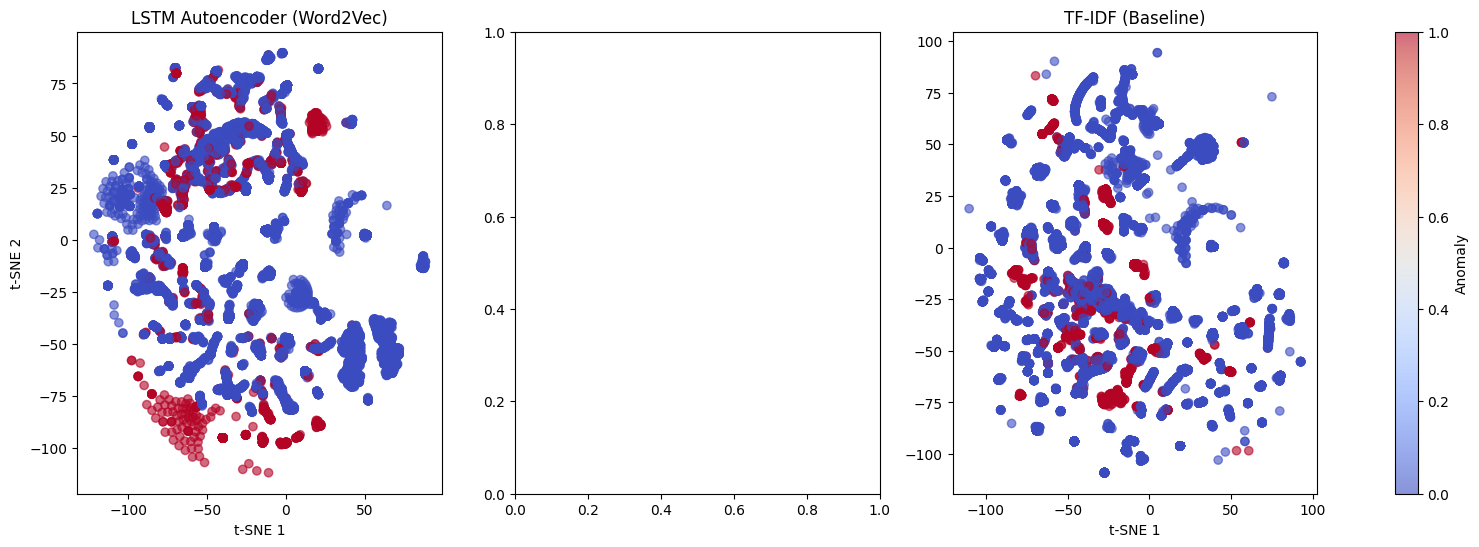

In [38]:
# 6b. Compare Latent Spaces (LSTM vs Transformer vs TF-IDF)

# Get Transformer Latent
transformer_model.eval()
with torch.no_grad():
    _, latent_trans = transformer_model(torch.FloatTensor(X_test_bert))
    latent_trans_np = latent_trans.numpy()

# Run t-SNE for all
print("Running t-SNE for comparison...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# 1. LSTM (Word2Vec)
emb_lstm = tsne.fit_transform(latent_test_np)

# 2. Transformer (BERT)
# emb_trans = tsne.fit_transform(latent_trans_np)

# 3. TF-IDF (PCA first to reduce dim for t-SNE speed)
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
tfidf_reduced = pca.fit_transform(X_test_tfidf)
emb_tfidf = tsne.fit_transform(tfidf_reduced)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LSTM
scatter1 = axes[0].scatter(emb_lstm[:, 0], emb_lstm[:, 1], c=y_test, cmap='coolwarm', alpha=0.6)
axes[0].set_title('LSTM Autoencoder (Word2Vec)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# # Transformer
# scatter2 = axes[1].scatter(emb_trans[:, 0], emb_trans[:, 1], c=y_test, cmap='coolwarm', alpha=0.6)
# axes[1].set_title('Transformer Autoencoder (BERT)')
# axes[1].set_xlabel('t-SNE 1')

# TF-IDF
scatter3 = axes[2].scatter(emb_tfidf[:, 0], emb_tfidf[:, 1], c=y_test, cmap='coolwarm', alpha=0.6)
axes[2].set_title('TF-IDF (Baseline)')
axes[2].set_xlabel('t-SNE 1')

plt.colorbar(scatter3, ax=axes.ravel().tolist(), label='Anomaly')
plt.show()